# Linear Models prediction task 

In [180]:
# Import libraries 
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandasql as pdsql
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

import random
np.random.seed(42)
random.seed(42)

In [ ]:
# Path to my data 
data_path = "project/microsoft_corp/data_clean.csv"

# Reading the data 
data = pd.read_csv(data_path, parse_dates=['date'])

# Adjust the index 
data = data.set_index('date')

# Display cleaned time series dataset
display(data.head())

,volume,adjprice,oil,gold,sp500,vix,rates_10y
date,,,,,,,
2010-01-04,38409100.0,23.077383,81.510002,1117.699951,1132.989990,20.040001,3.841
2010-01-05,49749600.0,23.084843,81.769997,1118.099976,1136.520020,19.350000,3.755
2010-01-06,58182400.0,22.943165,83.180000,1135.900024,1137.140015,19.160000,3.808
2010-01-07,50559700.0,22.704561,82.660004,1133.099976,1141.689941,19.059999,3.822
2010-01-08,51197400.0,22.861149,82.750000,1138.199951,1144.979980,18.129999,3.808


In [182]:
def create_dataset(series, window_size, lead_time):
    X, y = [], []

    # Ensure data is in numpy format for easier indexing
    if isinstance(series, pd.Series) or isinstance(series, pd.DataFrame):
        data = series.values
    else:
        data = series

    # We loop through the data, stopping before we run out of future values to predict
    for i in range(len(data) - window_size - lead_time + 1):
        # Input: sequence from i to i + window_size
        X.append(data[i : i + window_size])

        # Output: the value at lead_time steps after the window ends
        y.append(data[i + window_size + lead_time - 1])

    return np.array(X), np.array(y)

In [183]:
# Create the dataset using the parameters and the function defined 
target_col = 'adjprice'
window_size = 7
lead_time = 1

X, y = create_dataset(data[target_col], window_size=window_size, lead_time=lead_time)

print("Dataset Construction Complete.")
print(f"Shape of X: {X.shape}  -> (n_samples, window_size)")
print(f"Shape of y: {y.shape}      -> (n_samples,)")

Dataset Construction Complete.
Shape of X: (4017, 7)  -> (n_samples, window_size)
Shape of y: (4017,)      -> (n_samples,)


In [184]:
# As before, we take until 2019 for training, until 2022 for validation and then until 2026 for test
y_dates = data.index[window_size + lead_time - 1:]
train_end_idx = np.where(y_dates.year <= 2019)[0][-1] + 1
val_end_idx = np.where(y_dates.year <= 2022)[0][-1] + 1

X_train, y_train = X[:train_end_idx], y[:train_end_idx]
X_val, y_val = X[train_end_idx:val_end_idx], y[train_end_idx:val_end_idx]
X_test, y_test = X[val_end_idx:], y[val_end_idx:]

print(f"Train: {y_dates[0].date()} -> {y_dates[train_end_idx-1].date()}  ({len(X_train)}) ({round(len(X_train)/len(data)*100)}%)")
print(f"Val:   {y_dates[train_end_idx].date()} -> {y_dates[val_end_idx-1].date()}  ({len(X_val)}) ({round(len(X_val)/len(data)*100)}%)")
print(f"Test:  {y_dates[val_end_idx].date()} -> {y_dates[-1].date()}  ({len(X_test)}) ({round(len(X_test)/len(data)*100)}%)")

Train: 2010-01-13 -> 2019-12-31  (2509) (62%)
Val:   2020-01-02 -> 2022-12-30  (756) (19%)
Test:  2023-01-03 -> 2025-12-31  (752) (19%)


## Linear Autoregressive (AR) Model

**Mathematical definition:**
$$\hat{y}_{t+1} = w_0 + w_1 y_t + w_2 y_{t-1} + \dots + w_d y_{t-d+1}$$
$$adjprice(t+1) = w0 + w1·adjprice(t) + w2·adjprice(t-1) + ... + w7·adjprice(t-6)$$

Where:
*   $w_0$ is the intercept (bias).
*   $w_1, \dots, w_d$ are the **weights** learned by the model for each day in our window.


In [185]:
# Initialize the model 
model_ar = LinearRegression()

# 2. Train the model 
model_ar.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [186]:
# Retrieving the parameters
weights = model_ar.coef_
intercept = model_ar.intercept_

print(f"Intercept (w0): {intercept:.4f}")
for i, w in enumerate(weights):
    # i=0 is the oldest day in the window, i=6 is the most recent
    print(f"Weight for Day (t - {window_size - 1 - i}): {w:.4f}")

Intercept (w0): -0.0336
Weight for Day (t - 6): 0.0341
Weight for Day (t - 5): 0.0566
Weight for Day (t - 4): -0.0214
Weight for Day (t - 3): -0.0875
Weight for Day (t - 2): 0.1251
Weight for Day (t - 1): 0.0063
Weight for Day (t - 0): 0.8889


In [187]:
# Predict the price of the next day in the test set 
y_pred_ar = model_ar.predict(X_test)

print(f"Generated {len(y_pred_ar)} predictions.")
print(f"First 5 predictions (averages): {y_pred_ar[:5]}")
print(f"First 5 actual values: {y_test[:5]}")

Generated 752 predictions.
First 5 predictions (averages): [233.83511718 234.4760892  224.67043392 218.46930927 219.74151492]
First 5 actual values: [233.45281982 223.24081421 216.6244812  219.17747498 221.31147766]


It doesn't seems terrible

In [188]:
# Evaluation of the model 
mse_ar = mean_squared_error(y_test, y_pred_ar)
mae_ar = mean_absolute_error(y_test, y_pred_ar)
mape_ar = mean_absolute_percentage_error(y_test, y_pred_ar)
rmse_ar = root_mean_squared_error(y_test, y_pred_ar)
r2_ar = r2_score(y_test, y_pred_ar)

print(f"Linear Model MSE: {mse_ar:.4f}")
print(f"Linear Model MAE: {mae_ar:.4f}")
print(f"Linear Model MAPE: {mape_ar:.4f}")
print(f"Linear Model RMSE: {rmse_ar:.4f}")
print(f"Linear Model R2: {r2_ar:.4f}")

Linear Model MSE: 31.5163
Linear Model MAE: 4.0816
Linear Model MAPE: 0.0107
Linear Model RMSE: 5.6139
Linear Model R2: 0.9945


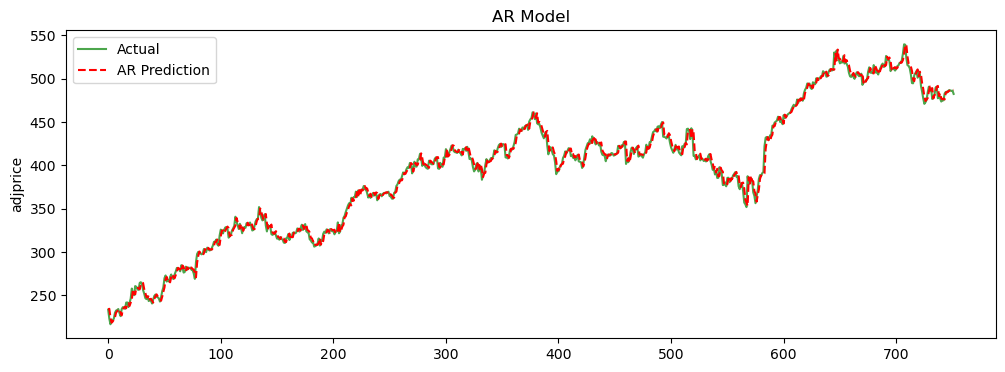

In [189]:
# Visualization 
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', color='green', alpha=0.7)
plt.plot(y_pred_ar, label='AR Prediction', color='red', linestyle='--')

plt.title("AR Model")
plt.ylabel("adjprice")
plt.legend()
plt.show()

## Hyperparameter Tuning 

For this model, we don't have hyperparameters to adjust except for relugarizations, but we can try to use different windows size, in order to have an idea on the relationship with the output. 

In [190]:
# Use a "gridsearch" style code to cycle inside different candidates of windows size 
# and validate them inside the validation set 
candidate_window_sizes = [1, 3, 5, 7, 10, 14, 21, 27]
val_scores = {}

for w in candidate_window_sizes:
    X_w, y_w = create_dataset(data[target_col], window_size=w, lead_time=lead_time)
    y_dates_w = data.index[w + lead_time - 1:]
    train_end_w = np.where(y_dates_w.year <= 2019)[0][-1] + 1
    val_end_w = np.where(y_dates_w.year <= 2022)[0][-1] + 1

    X_train_w, y_train_w = X_w[:train_end_w], y_w[:train_end_w]
    X_val_w, y_val_w = X_w[train_end_w:val_end_w], y_w[train_end_w:val_end_w]

    model_w = LinearRegression()
    model_w.fit(X_train_w, y_train_w)
    y_pred_val_w = model_w.predict(X_val_w)

    val_scores[w] = mean_squared_error(y_val_w, y_pred_val_w)
    print(f"window_size={w:2d} -> Validation MSE: {val_scores[w]:.4f}")

best_window_size = min(val_scores, key=val_scores.get)
print(f"\nMigliore window_size su validation: {best_window_size} (MSE={val_scores[best_window_size]:.4f})")

window_size= 1 -> Validation MSE: 21.9853
window_size= 3 -> Validation MSE: 21.9521
window_size= 5 -> Validation MSE: 22.1325
window_size= 7 -> Validation MSE: 22.3401
window_size=10 -> Validation MSE: 22.0946
window_size=14 -> Validation MSE: 22.0834
window_size=21 -> Validation MSE: 22.1847
window_size=27 -> Validation MSE: 22.2597

Migliore window_size su validation: 3 (MSE=21.9521)


## ARX Model 

**Mathematical definition**:

$$\text{adj\_price}(t+1) = w_0 + \sum_{j} (w_j \cdot x_j)$$

- $\text{window\_size} \times \text{m\_columns}$ terms: $j = 1, \dots, 49$

In [191]:
data.columns

Index(['volume', 'adjprice', 'oil', 'gold', 'sp500', 'vix', 'rates_10y'], dtype='object')

In [192]:
exog_cols = ['volume', 'oil', 'gold', 'sp500', 'vix', 'rates_10y']
corr_target = data[[target_col] + exog_cols].corr()[target_col].sort_values(ascending=False)
print(corr_target)

adjprice     1.000000
sp500        0.980899
gold         0.850261
rates_10y    0.509189
vix          0.063724
oil         -0.074573
volume      -0.399429
Name: adjprice, dtype: float64


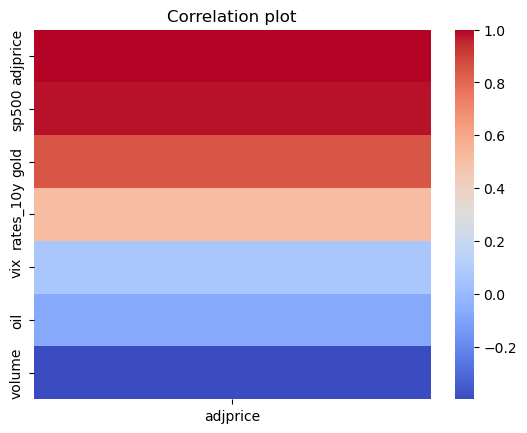

In [193]:
sns.heatmap(corr_target.to_frame(), cmap="coolwarm")
plt.title("Correlation plot")
plt.show()

In [194]:
# Create the dataset using the parameters and the function defined 
target_col = 'adjprice'
window_size = 7
lead_time = 1

exog_cols = ['volume', 'oil', 'gold', 'sp500', 'vix', 'rates_10y']
arx_cols = [target_col] + exog_cols

X_multi, y_multi = create_dataset(data[arx_cols], window_size=window_size, lead_time=lead_time)

print("Dataset Construction Complete.")
print(f"Shape of X_multi: {X_multi.shape}  -> (n_samples, window_size)")
print(f"Shape of y_multi: {y_multi.shape}      -> (n_samples,)")

Dataset Construction Complete.
Shape of X_multi: (4017, 7, 7)  -> (n_samples, window_size)
Shape of y_multi: (4017, 7)      -> (n_samples,)


In [195]:
# Flatten the last two dimensions
n_samples_m = X_multi.shape[0]
X_multi_flat = X_multi.reshape(n_samples_m, -1)

print(f"Flattened X for ARX: {X_multi_flat.shape}  -> (samples, window_size * n_features)")

Flattened X for ARX: (4017, 49)  -> (samples, window_size * n_features)


In [196]:
# Split strategy 
X_train_x = X_multi_flat[:train_end_idx]
y_train_x = y_multi[:train_end_idx][:, 0]  # column 0 = target (adjprice)

X_val_x = X_multi_flat[train_end_idx:val_end_idx]
y_val_x = y_multi[train_end_idx:val_end_idx][:, 0]

X_test_x = X_multi_flat[val_end_idx:]
y_test_x = y_multi[val_end_idx:][:, 0]

print(f"ARX training features: {X_train_x.shape[1]}")
print(f"Train: {X_train_x.shape[0]} | Val: {X_val_x.shape[0]} | Test: {X_test_x.shape[0]}")

ARX training features: 49
Train: 2509 | Val: 756 | Test: 752


In [197]:
# Model phase 
model_arx = LinearRegression()

# Fit
model_arx.fit(X_train_x, y_train_x)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [198]:
# Predict
y_pred_arx = model_arx.predict(X_test_x)

# Check 
print(f"Generated {len(y_pred_arx)} predictions.")

Generated 752 predictions.


In [199]:
# Evaluation metrics 
mse_arx = mean_squared_error(y_test_x, y_pred_arx)
mae_arx = mean_absolute_error(y_test_x, y_pred_arx)
mape_arx = mean_absolute_percentage_error(y_test_x, y_pred_arx)
rmse_arx = root_mean_squared_error(y_test_x, y_pred_arx)
r2_arx = r2_score(y_test_x, y_pred_arx)

print(f"Linear ARX Model MSE:  {mse_arx:.4f}")
print(f"Linear ARX Model MAE:  {mae_arx:.4f}")
print(f"Linear ARX Model MAPE: {mape_arx:.4f}")
print(f"Linear ARX Model RMSE: {rmse_arx:.4f}")
print(f"Linear ARX Model R2:   {r2_arx:.4f}")

print(f"\nComparison vs AR:")
print(f"AR  MSE: {mse_ar:.4f}")
print(f"ARX MSE: {mse_arx:.4f}")

Linear ARX Model MSE:  31.6474
Linear ARX Model MAE:  4.0958
Linear ARX Model MAPE: 0.0107
Linear ARX Model RMSE: 5.6256
Linear ARX Model R2:   0.9944

Comparison vs AR:
AR  MSE: 31.5163
ARX MSE: 31.6474


In [200]:
feature_labels = [f"{col}(t-{window_size-1-lag})" for lag in range(window_size) for col in arx_cols]

importance = pd.DataFrame({
    'feature': feature_labels,
    'importance': np.abs(model_arx.coef_)
}).sort_values('importance', ascending=False).reset_index().head(10)

print(importance)

   index         feature  importance
0     42   adjprice(t-0)    0.852251
1     20  rates_10y(t-4)    0.727734
2     34  rates_10y(t-2)    0.566573
3     41  rates_10y(t-1)    0.504149
4     27  rates_10y(t-3)    0.402806
5     28   adjprice(t-2)    0.156576
6      6  rates_10y(t-6)    0.151491
7     21   adjprice(t-3)    0.120499
8     48  rates_10y(t-0)    0.102028
9      0   adjprice(t-6)    0.064649


## Hyperparmeter tuning

For this model, we don't have hyperparameters to adjust except for relugarizations, but we can try to use different windows size, in order to have an idea on the relationship with the output. 

In [201]:
# Use a "gridsearch" style code to cycle inside different candidates of window size
# and validate them inside the validation set
candidate_window_sizes = [1, 3, 7, 9, 14, 21, 28]
val_scores = {}

exog_cols = ['volume', 'oil', 'gold', 'sp500', 'vix', 'rates_10y']
arx_cols = [target_col] + exog_cols

for w in candidate_window_sizes:
    X_w, y_w = create_dataset(data[arx_cols], window_size=w, lead_time=lead_time)
    X_w = X_w.reshape(X_w.shape[0], -1)
    # y_w has shape (samples, n_features); column 0 = adjprice
    y_w = y_w[:, 0]

    y_dates_w = data.index[w + lead_time - 1:]
    train_end_w = np.where(y_dates_w.year <= 2019)[0][-1] + 1
    val_end_w = np.where(y_dates_w.year <= 2022)[0][-1] + 1

    X_train_w, y_train_w = X_w[:train_end_w], y_w[:train_end_w]
    X_val_w, y_val_w = X_w[train_end_w:val_end_w], y_w[train_end_w:val_end_w]

    model_w = LinearRegression()
    model_w.fit(X_train_w, y_train_w)
    y_pred_val_w = model_w.predict(X_val_w)

    val_scores[w] = mean_squared_error(y_val_w, y_pred_val_w)
    print(f"window_size={w:2d} -> Validation MSE: {val_scores[w]:.4f}")

best_window_size = min(val_scores, key=val_scores.get)
print(f"\nBest window_size on validation: {best_window_size} (MSE={val_scores[best_window_size]:.4f})")

window_size= 1 -> Validation MSE: 21.9304
window_size= 3 -> Validation MSE: 22.0418
window_size= 7 -> Validation MSE: 22.5374
window_size= 9 -> Validation MSE: 22.2634
window_size=14 -> Validation MSE: 22.4144
window_size=21 -> Validation MSE: 22.5219
window_size=28 -> Validation MSE: 22.6485

Best window_size on validation: 1 (MSE=21.9304)


,MSE,MAE,MAPE,RMSE,R2
Model,,,,,
Linear AR,31.516328,4.081643,0.010686,5.613941,0.994451
Linear ARX,31.647363,4.095818,0.010720,5.625599,0.994428


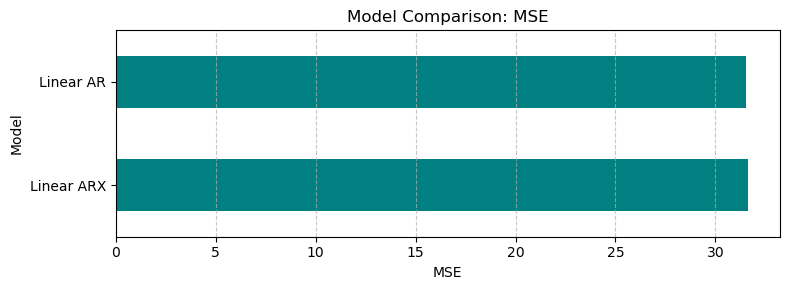

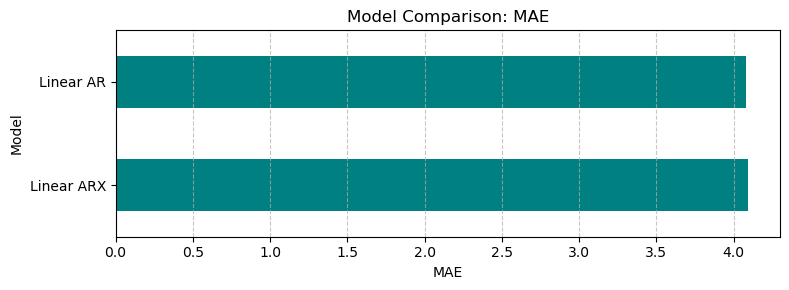

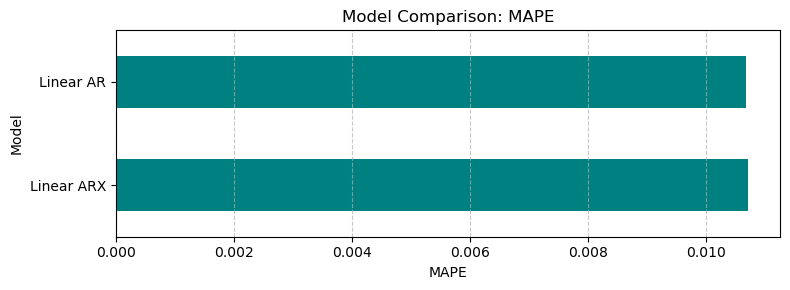

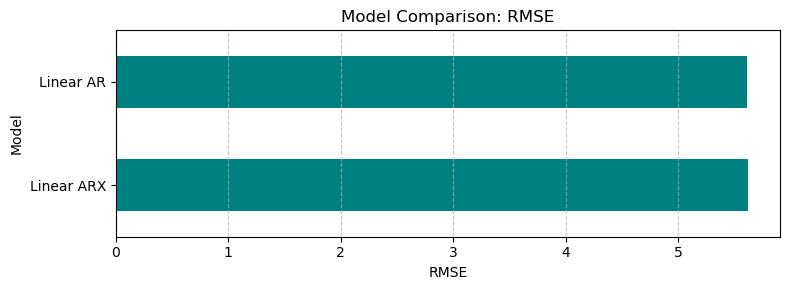

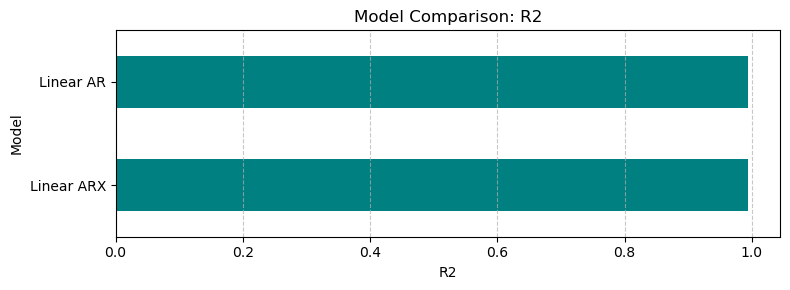

In [202]:
# Model Comparison
performance_metrics = [
    {'Model': 'Linear AR', 'MSE': mse_ar, 'MAE': mae_ar, 'MAPE': mape_ar, 'RMSE': rmse_ar, 'R2': r2_ar},
    {'Model': 'Linear ARX', 'MSE': mse_arx, 'MAE': mae_arx, 'MAPE': mape_arx, 'RMSE': rmse_arx, 'R2': r2_arx},
]
df_results = pd.DataFrame(performance_metrics).set_index('Model')
display(df_results)

for metric in ['MSE', 'MAE', 'MAPE', 'RMSE', 'R2']:
    plt.figure(figsize=(8, 3))
    df_results[metric].plot(kind='barh', color='teal')
    plt.gca().invert_yaxis()
    plt.title(f"Model Comparison: {metric}")
    plt.xlabel(metric)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()